<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 12px; margin-bottom: 20px;">
  <h1 style="color: #e94560; font-size: 2em; margin: 0;">Projet SAE — Analyse des IPO américaines</h1>
  <h2 style="color: #a8dadc; font-size: 1.2em; margin: 10px 0 20px;">Taux bas (2019–2021) vs Taux élevés (2022–2024)</h2>
  <p style="color: #ccc; margin: 4px 0;"><b style='color:white'>Étudiants :</b> Simon Hamelin · Francisco Tornos · Damien Kae-Nune · Yanis Amaouche</p>
  <p style="color: #ccc; margin: 4px 0;"><b style='color:white'>Superviseur :</b> M. Frédéric LOSS</p>
  <p style="color: #ccc; margin: 4px 0;"><b style='color:white'>Formation :</b> ING1 FISA Mathématiques Appliquées — Ingénierie Financière — CY Tech</p>
  <p style="color: #ccc; margin: 4px 0;"><b style='color:white'>Année universitaire :</b> 2025–2026</p>
</div>

---

## Problématique

> *L'environnement de taux d'intérêt élevés (2022–2024) a-t-il structurellement modifié les caractéristiques (taille, rentabilité, secteur) et la performance au premier jour des entreprises accédant au marché IPO américain, par rapport à la période de taux bas (2019–2021) ?*

## Hypothèses testées

| # | Hypothèse | Variable clé | Test |
|---|-----------|--------------|------|
| **H1** | Les entreprises introduites en 2022–2024 sont plus matures et plus sélectionnées | Âge médian, Note SCOOP | Mann-Whitney |
| **H2** | L'underpricing moyen est plus faible en période de taux élevés | Underpricing J0 | Mann-Whitney + IC 95% |
| **H3** | La composition sectorielle diffère significativement entre les deux cohortes | Part Tech / Finance | Test du Chi-2 |
| **H4** | L'effet des taux sur l'underpricing est isolable toutes choses égales par ailleurs | Coefficient Fed Rate | Régression OLS |

## Plan du notebook

| Section | Contenu |
|---------|---------|
| **0** | Imports et configuration globale |
| **1** | Chargement et nettoyage des données |
| **2** | Statistiques descriptives comparatives |
| **3** | Intervalles de confiance à 95 % |
| **4** | Tests de Mann-Whitney (H1 & H2) |
| **5** | Analyse de la composition sectorielle (H3) |
| **6** | Régression OLS multivariée (H4) |

---

## Section 0 — Imports et configuration

In [29]:
# ── Manipulation de données ────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Tests statistiques ─────────────────────────────────────────────────────────
import scipy.stats as st
from scipy.stats import mannwhitneyu, chi2_contingency

# ── Régression OLS ─────────────────────────────────────────────────────────────
import statsmodels.api as sm

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Configuration globale ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

# Palette cohérente pour les deux cohortes
PALETTE = {
    'Taux Bas (2019-2021)':     '#4A90D9',   # bleu
    'Taux Élevés (2022-2024)':  '#E85D5D',   # rouge
}

print('✅ Environnement configuré.')

✅ Environnement configuré.


---
## Section 1 — Chargement et nettoyage des données

### Source
Le fichier `data/dataset_IPO_merged_complete.xlsx` est le dataset consolidé issu de la fusion de trois sources :
- **Dataset principal** (`dataset_complet_final.xlsx`) : tickers, dates d'IPO, prix d'offre/clôture, underpricing, rendements, taux Fed, secteur SIC.
- **Bases Jay Ritter** (`IPO-age.xlsx`) : âge de l'entreprise à l'introduction, présence de fonds VC, flag Internet.
- **SCOOP Rating** (`SCOOP-Rating-Performance.xlsx`) : note d'attractivité attribuée par les banques d'investissement avant l'introduction (1 à 5 étoiles).

### Filtres d'inclusion appliqués en amont
| Critère | Valeur |
|---------|--------|
| Prix d'offre (open_px) | ≥ 5 $ |
| Taille de l'émission (ipo_size_m) | ≥ 50 M$ |
| Marché | NYSE ou Nasdaq uniquement |
| Type | SPACs et direct listings exclus |

In [30]:
# ── 1.1  Chargement ────────────────────────────────────────────────────────────
df = pd.read_excel('outputs/dataset_IPO_merged_complete.xlsx')

# ── 1.2  Création de la colonne cohorte ────────────────────────────────────────
df['cohorte'] = np.where(
    df['year'] <= 2021,
    'Taux Bas (2019-2021)',
    'Taux Élevés (2022-2024)'
)

# ── 1.3  Vérification du dataset ───────────────────────────────────────────────
print(f'Dimensions du dataset : {df.shape[0]} IPOs × {df.shape[1]} colonnes')
print()

# Taux de remplissage des colonnes clés
cols_cles = ['underpricing', 'ret_30d', 'fed_rate', 'ipo_size_m',
             'company_age', 'VC', 'star_rating', 'sector']
print('Taux de remplissage des variables clés :')
for col in cols_cles:
    if col in df.columns:
        n_ok  = df[col].notna().sum()
        pct   = n_ok / len(df) * 100
        print(f'  {col:<15} : {n_ok:>3}/{len(df)}  ({pct:.1f}%)')

print()
print('Répartition par cohorte :')
print(df.groupby(['cohorte', 'year'])['ticker'].count().to_string())

# Aperçu
display(df[['ticker', 'year', 'cohorte', 'underpricing',
            'ipo_size_m', 'fed_rate', 'sector', 'company_age']].head(5))

Dimensions du dataset : 308 IPOs × 25 colonnes

Taux de remplissage des variables clés :
  underpricing    : 308/308  (100.0%)
  ret_30d         : 308/308  (100.0%)
  fed_rate        : 308/308  (100.0%)
  ipo_size_m      : 308/308  (100.0%)
  company_age     : 287/308  (93.2%)
  VC              : 287/308  (93.2%)
  star_rating     :  94/308  (30.5%)
  sector          : 308/308  (100.0%)

Répartition par cohorte :
cohorte                  year
Taux Bas (2019-2021)     2019    48
                         2020    92
                         2021    90
Taux Élevés (2022-2024)  2022    15
                         2023    23
                         2024    40


,ticker,year,cohorte,underpricing,ipo_size_m,fed_rate,sector,company_age
0,FVRR,2019,Taux Bas (2019-2021),0.5346,573.1960,2.1600,Consumer,9.0000
1,GGRP,2021,Taux Bas (2019-2021),0.5030,90.9838,0.0800,Tech,NaN
2,BYND,2019,Taux Bas (2019-2021),0.4293,1063.4740,2.1600,Industrials,10.0000
3,LMND,2020,Taux Bas (2019-2021),0.3865,919.6973,0.3800,Finance,5.0000
4,MAX,2020,Taux Bas (2019-2021),0.3852,125.4972,0.3800,Consumer,6.0000


---
## Section 2 — Statistiques descriptives comparatives

### Objectif
Dresser un portrait chiffré des deux cohortes sur toutes les variables clés **avant** tout test formel.  
L'analyse est présentée à deux niveaux :
1. **Par cohorte** (agrégé) — vue d'ensemble sur 2019–2021 vs 2022–2024.
2. **Par année** — pour visualiser l'hétérogénéité interne et l'effet 2021 (euphorie spéculative).

### Variables analysées
| Variable | Description |
|----------|-------------|
| `underpricing` | (Clôture J0 − Prix offre) / Prix offre |
| `ret_30d` | Rendement ajusté à J+30 |
| `ipo_size_m` | Montant levé lors de l'IPO (en M$) |
| `company_age` | Âge de l'entreprise au moment de l'introduction |
| `star_rating` | Note SCOOP (1–5 étoiles) |

In [31]:
# ── 2.1  Tableau descriptif par cohorte ────────────────────────────────────────
vars_num = ['underpricing', 'ret_30d', 'ipo_size_m', 'company_age', 'star_rating']

desc = (
    df.groupby('cohorte')[vars_num]
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
)

print('═' * 70)
print('TABLEAU 1 — Statistiques descriptives par cohorte')
print('═' * 70)
display(desc.round(4))

# ── 2.2  Tableau récapitulatif simplifié (prêt pour le rapport) ────────────────
synthese = df.groupby('cohorte').agg(
    N                   = ('ticker',       'count'),
    Underpricing_moyen  = ('underpricing', 'mean'),
    Underpricing_median = ('underpricing', 'median'),
    Rendement_30j_moyen = ('ret_30d',      'mean'),
    Taille_mediane_M    = ('ipo_size_m',   'median'),
    Age_median          = ('company_age',  'median'),
    Note_SCOOP_moyenne  = ('star_rating',  'mean'),
).round(4)

print()
print('═' * 70)
print('TABLEAU 2 — Synthèse comparative (indicateurs clés)')
print('═' * 70)
display(synthese)

══════════════════════════════════════════════════════════════════════
TABLEAU 1 — Statistiques descriptives par cohorte
══════════════════════════════════════════════════════════════════════


underpricing                                        \
                               count    mean  median    std     min    max   
cohorte                                                                      
Taux Bas (2019-2021)             230  0.0322  0.0236 0.1376 -0.3487 0.5346   
Taux Élevés (2022-2024)           78 -0.0214 -0.0069 0.1001 -0.3277 0.2817   

                        ret_30d                        ... company_age  \
                          count    mean median    std  ...      median   
cohorte                                                ...               
Taux Bas (2019-2021)        230  0.0405 0.0000 0.2850  ...     13.0000   
Taux Élevés (2022-2024)      78 -0.0282 0.0231 0.2588  ...     19.0000   

                                                star_rating                \
                            std    min      max       count   mean median   
cohorte                                                                     
Taux Bas (2019-2021)    24.4500 1.0000 170.0000          90 2.4222 3.0000   
Taux Élevés (2022-2024) 36.6500 1.0000 249.0000           4 2.0000 2.0000   

                                              
                           std    min    max  
cohorte                                       
Taux Bas (2019-2021)    0.8070 1.0000 4.0000  
Taux Élevés (2022-2024) 0.8165 1.0000 3.0000  

[2 rows x 30 columns]


══════════════════════════════════════════════════════════════════════
TABLEAU 2 — Synthèse comparative (indicateurs clés)
══════════════════════════════════════════════════════════════════════


,N,Underpricing_moyen,Underpricing_median,Rendement_30j_moyen,Taille_mediane_M,Age_median,Note_SCOOP_moyenne
cohorte,,,,,,,
Taux Bas (2019-2021),230,0.0322,0.0236,0.0405,211.2936,13.0000,2.4222
Taux Élevés (2022-2024),78,-0.0214,-0.0069,-0.0282,125.7913,19.0000,2.0000


In [32]:
# ── 2.3  Tableau par année (pour identifier l'effet 2021) ──────────────────────
par_annee = df.groupby('year').agg(
    N                  = ('ticker',       'count'),
    Underpricing_moyen = ('underpricing', 'mean'),
    Age_median         = ('company_age',  'median'),
    Taux_Fed_moyen     = ('fed_rate',     'mean'),
).round(4)

print('═' * 70)
print('TABLEAU 3 — Indicateurs clés par année (2019–2024)')
print('═' * 70)
display(par_annee)

══════════════════════════════════════════════════════════════════════
TABLEAU 3 — Indicateurs clés par année (2019–2024)
══════════════════════════════════════════════════════════════════════


,N,Underpricing_moyen,Age_median,Taux_Fed_moyen
year,,,,
2019,48,0.0268,11.0000,2.1600
2020,92,0.0244,12.0000,0.3800
2021,90,0.0431,14.5000,0.0800
2022,15,-0.0706,23.0000,1.6800
2023,23,-0.0390,17.0000,5.0200
2024,40,0.0072,19.0000,5.1400


C:\Users\X515\AppData\Local\Temp\ipykernel_24740\2172968565.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\X515\AppData\Local\Temp\ipykernel_24740\2172968565.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\X515\AppData\Local\Temp\ipykernel_24740\2172968565.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\X515\AppData\Local\Temp\ipykernel_24740\2172968565.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

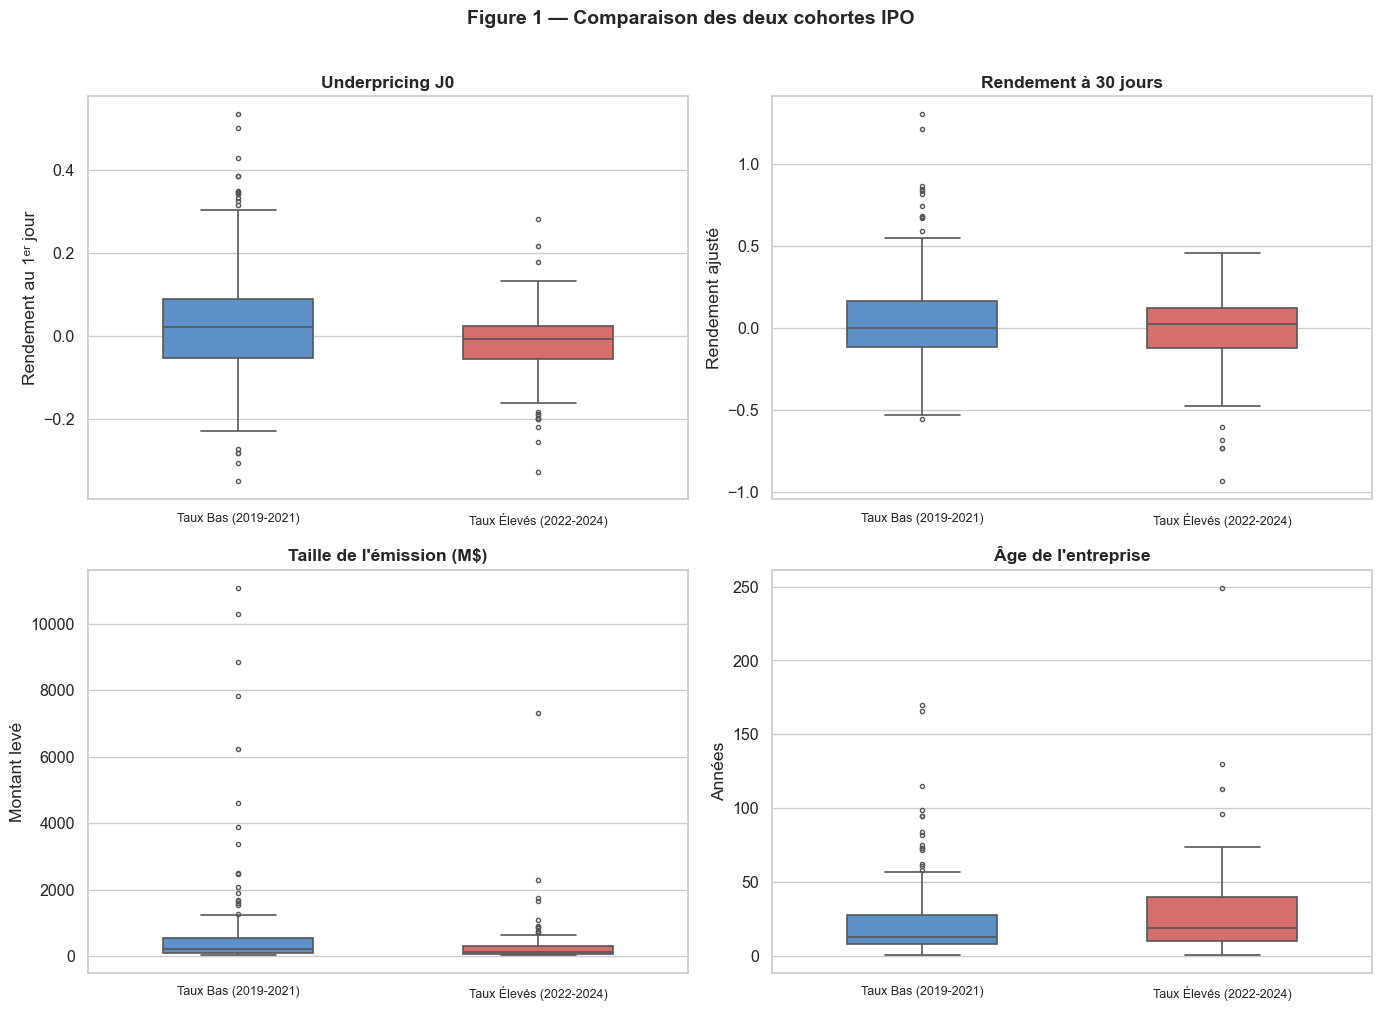

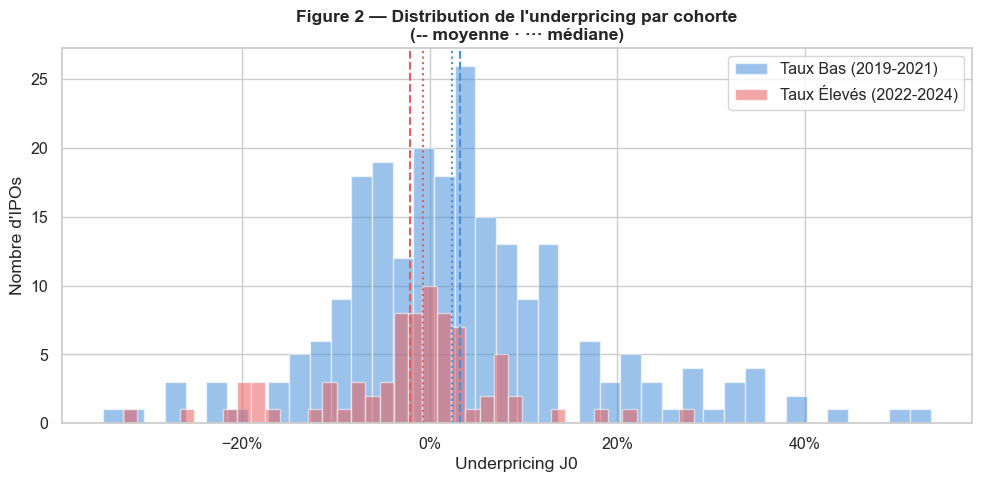

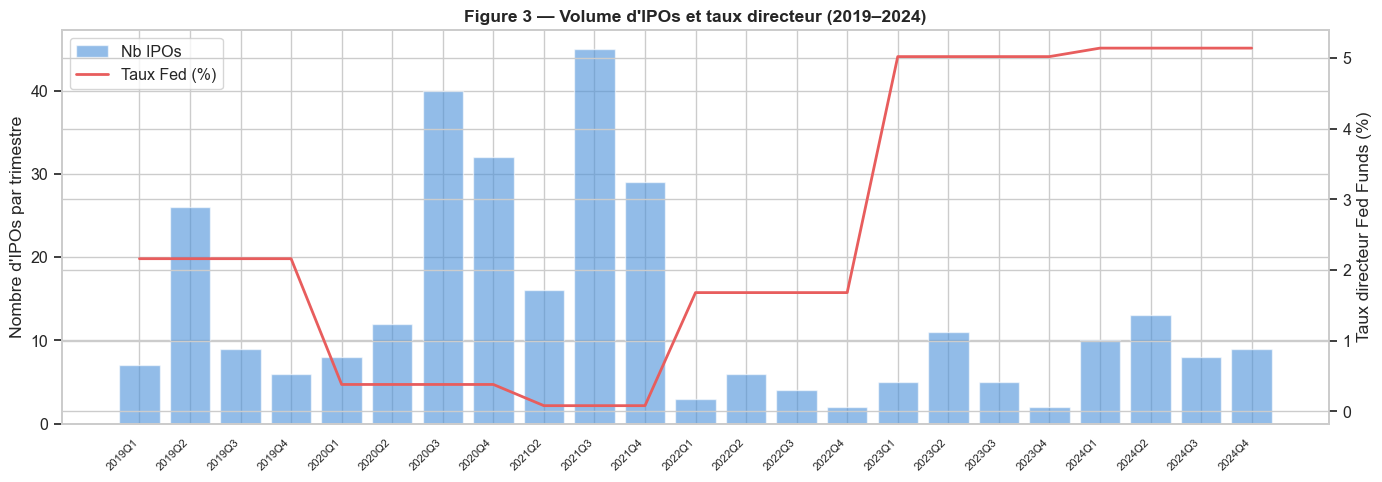

In [33]:
# ── 2.4  Visualisations ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 1 — Comparaison des deux cohortes IPO', fontsize=14, fontweight='bold', y=1.01)

plot_vars = [
    ('underpricing', 'Underpricing J0',          'Rendement au 1ᵉʳ jour'),
    ('ret_30d',      'Rendement à 30 jours',      'Rendement ajusté'),
    ('ipo_size_m',   'Taille de l\'émission (M$)', 'Montant levé'),
    ('company_age',  'Âge de l\'entreprise',       'Années'),
]

for ax, (var, title, ylabel) in zip(axes.flat, plot_vars):
    sns.boxplot(
        data=df, x='cohorte', y=var, ax=ax,
        palette=PALETTE, width=0.5, fliersize=3, linewidth=1.2
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('outputs/fig1_boxplots_comparatifs.png', dpi=150, bbox_inches='tight')
plt.show()

# Distribution de l'underpricing
fig2, ax2 = plt.subplots(figsize=(10, 5))
for label, color in PALETTE.items():
    subset = df[df['cohorte'] == label]['underpricing'].dropna()
    ax2.hist(subset, bins=40, alpha=0.55, color=color, label=label, edgecolor='white')
    ax2.axvline(subset.mean(),   color=color, linestyle='--', linewidth=1.5)
    ax2.axvline(subset.median(), color=color, linestyle=':',  linewidth=1.5)

ax2.set_title('Figure 2 — Distribution de l\'underpricing par cohorte\n(-- moyenne · ··· médiane)', fontweight='bold')
ax2.set_xlabel('Underpricing J0')
ax2.set_ylabel('Nombre d\'IPOs')
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.legend()
plt.tight_layout()
plt.savefig('outputs/fig2_distribution_underpricing.png', dpi=150, bbox_inches='tight')
plt.show()

# Volume d'IPO par trimestre + taux Fed
df['quarter'] = pd.PeriodIndex(df['ipo_date'], freq='Q').astype(str)
vol_trim = df.groupby('quarter')['ticker'].count()
taux_trim = df.groupby('quarter')['fed_rate'].mean()

fig3, ax3 = plt.subplots(figsize=(14, 5))
ax3b = ax3.twinx()

ax3.bar(range(len(vol_trim)), vol_trim.values, color='#4A90D9', alpha=0.6, label='Nb IPOs')
ax3b.plot(range(len(taux_trim)), taux_trim.values, color='#E85D5D', linewidth=2, label='Taux Fed (%)')

step = max(1, len(vol_trim) // 12)
ax3.set_xticks(range(0, len(vol_trim), step))
ax3.set_xticklabels(vol_trim.index[::step], rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Nombre d\'IPOs par trimestre')
ax3b.set_ylabel('Taux directeur Fed Funds (%)')
ax3.set_title('Figure 3 — Volume d\'IPOs et taux directeur (2019–2024)', fontweight='bold')

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('outputs/fig3_volume_taux.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Intervalles de confiance à 95 %

### Objectif
Évaluer si les écarts observés entre cohortes sont **statistiquement précis** avant de recourir aux tests formels.  
Si les intervalles de confiance des deux groupes **ne se chevauchent pas**, la différence est significative au seuil de 5 %.

### Méthodes
- **IC sur la moyenne** : loi de Student — `scipy.stats.t.interval(0.95, df=n−1, loc=mean, scale=sem)`
- **IC sur les proportions** : méthode de Wilson (adaptée aux petits échantillons)

══════════════════════════════════════════════════════════════════════
TABLEAU 4 — Intervalles de confiance à 95 % (par variable et cohorte)
══════════════════════════════════════════════════════════════════════


,Variable,Cohorte,Moyenne,IC_inf,IC_sup
0,Underpricing J0,Taux Bas (2019-2021),0.0322,0.0144,0.0501
1,Underpricing J0,Taux Élevés (2022-2024),-0.0214,-0.0440,0.0012
2,Rendement 30 j,Taux Bas (2019-2021),0.0405,0.0034,0.0775
3,Rendement 30 j,Taux Élevés (2022-2024),-0.0282,-0.0865,0.0302
4,Âge médian,Taux Bas (2019-2021),21.8318,18.5372,25.1263
5,Âge médian,Taux Élevés (2022-2024),31.5205,22.9695,40.0716
6,Taille émission (M$),Taux Bas (2019-2021),612.2678,432.0533,792.4823
7,Taille émission (M$),Taux Élevés (2022-2024),392.5541,191.5763,593.5320


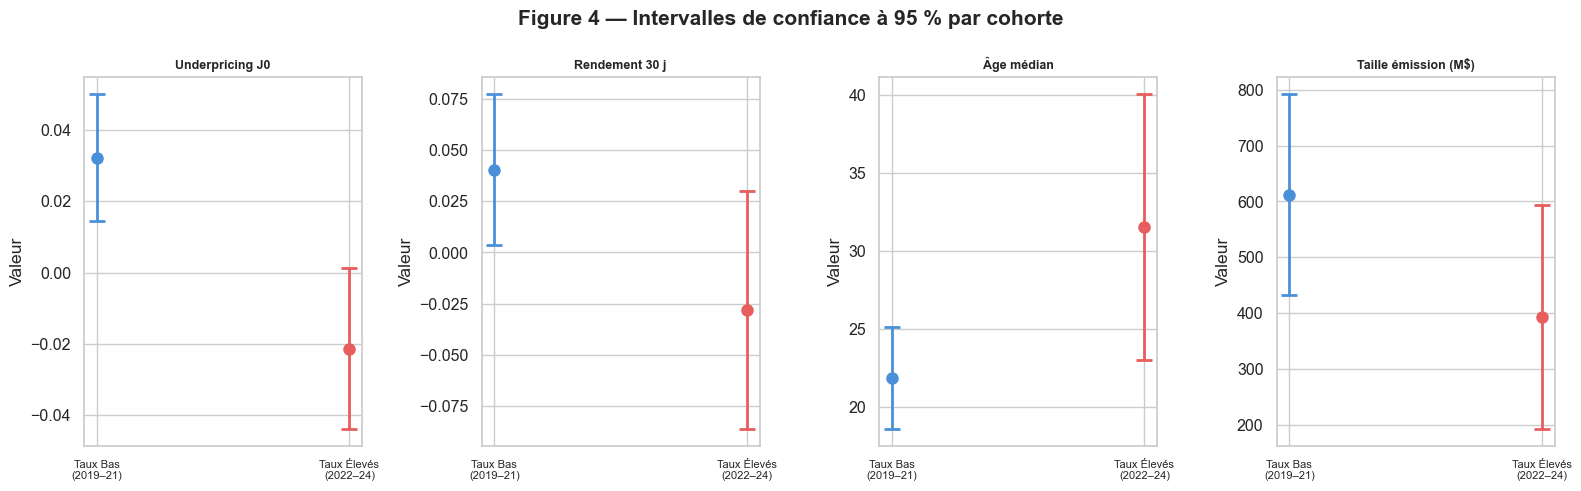

In [34]:
# ── 3.1  Fonction de calcul des IC ─────────────────────────────────────────────
def ic_moyenne(serie: pd.Series, conf: float = 0.95):
    """Retourne (moyenne, borne_inf, borne_sup) de l'IC à 95 % sur la moyenne."""
    serie = serie.dropna()
    n    = len(serie)
    mean = serie.mean()
    sem  = st.sem(serie)
    lo, hi = st.t.interval(conf, df=n - 1, loc=mean, scale=sem)
    return mean, lo, hi

# ── 3.2  Calcul des IC pour chaque variable et chaque cohorte ──────────────────
vars_ic = [
    ('underpricing', 'Underpricing J0'),
    ('ret_30d',      'Rendement 30 j'),
    ('company_age',  'Âge médian'),
    ('ipo_size_m',   'Taille émission (M$)'),
]

rows = []
for var, label in vars_ic:
    for cohorte in df['cohorte'].unique():
        serie = df[df['cohorte'] == cohorte][var]
        mean, lo, hi = ic_moyenne(serie)
        rows.append({'Variable': label, 'Cohorte': cohorte,
                     'Moyenne': mean, 'IC_inf': lo, 'IC_sup': hi})

df_ic = pd.DataFrame(rows)

print('═' * 70)
print('TABLEAU 4 — Intervalles de confiance à 95 % (par variable et cohorte)')
print('═' * 70)
display(df_ic.round(4))

# ── 3.3  Error bar plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(vars_ic), figsize=(16, 5))
fig.suptitle('Figure 4 — Intervalles de confiance à 95 % par cohorte', fontweight='bold')

cohortes  = df['cohorte'].unique()
couleurs  = [PALETTE[c] for c in cohortes]
x_pos     = np.arange(len(cohortes))

for ax, (var, label) in zip(axes, vars_ic):
    for i, (cohorte, couleur) in enumerate(zip(cohortes, couleurs)):
        mean, lo, hi = ic_moyenne(df[df['cohorte'] == cohorte][var])
        ax.errorbar(i, mean, yerr=[[mean - lo], [hi - mean]],
                    fmt='o', color=couleur, markersize=8,
                    capsize=6, capthick=2, linewidth=2)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Taux Bas\n(2019–21)', 'Taux Élevés\n(2022–24)'], fontsize=8)
    ax.set_title(label, fontweight='bold', fontsize=9)
    ax.set_ylabel('Valeur')

plt.tight_layout()
plt.savefig('outputs/fig4_intervalles_confiance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Tests de Mann-Whitney

### Pourquoi Mann-Whitney ?
Les distributions de rendements et d'underpricing sont fortement **asymétriques et à queues épaisses** (kurtosis élevée, confirmé par le test de Jarque-Bera dans l'OLS).  
Le test de Mann-Whitney est **non paramétrique** : il ne suppose pas la normalité et compare les rangs des observations entre deux groupes.

### Tests réalisés

| Hypothèse | Variable | Direction attendue | Paramètre `alternative` |
|-----------|----------|--------------------|-------------------------|
| H1 — Sélection (âge) | `company_age` | Taux élevés > Taux bas | `'greater'` |
| H1 — Sélection (note) | `star_rating` | Taux élevés > Taux bas | `'greater'` |
| H2 — Underpricing | `underpricing` | Taux élevés < Taux bas | `'less'` |
| H2 — Rendement 30j | `ret_30d` | Taux élevés > Taux bas | `'greater'` |

> **Seuil :** α = 0,05. Si p-value < α, on rejette H₀ (distributions identiques).

════════════════════════════════════════════════════════════════════════════════
TABLEAU 5 — Résultats des tests de Mann-Whitney
════════════════════════════════════════════════════════════════════════════════


,Hypothèse,Variable,N_bas,N_haut,Stat_U,p-value,Décision
0,H1 — Âge plus élevé en taux élevés,company_age,214,73,6198.0000,0.0042,✅ Rejet H₀
1,H1 — Note SCOOP plus élevée en taux élevés,star_rating,90,4,233.0000,0.8610,⚠️ Non rejeté
2,H2 — Underpricing plus bas en taux élevés,underpricing,230,78,10918.5000,0.0021,✅ Rejet H₀
3,H2 — Rendement 30j plus stable en taux élevés,ret_30d,230,78,9287.0000,0.6798,⚠️ Non rejeté


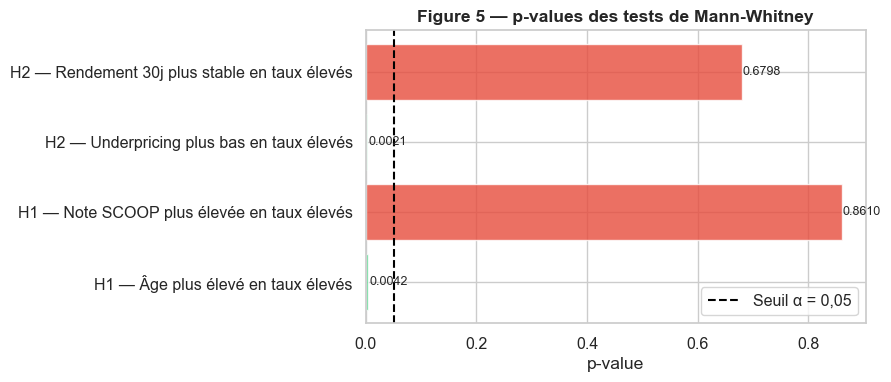

In [35]:
# ── 4.1  Séparation des deux cohortes ──────────────────────────────────────────
g_bas   = df[df['cohorte'] == 'Taux Bas (2019-2021)']
g_haut  = df[df['cohorte'] == 'Taux Élevés (2022-2024)']

def test_mw(var, alternative, label):
    """Effectue un test de Mann-Whitney et retourne un dict de résultats."""
    a = g_bas[var].dropna()
    b = g_haut[var].dropna()
    stat, p = mannwhitneyu(a, b, alternative=alternative)
    decision = '✅ Rejet H₀' if p < 0.05 else '⚠️  Non rejeté'
    return {'Hypothèse': label, 'Variable': var,
            'N_bas': len(a), 'N_haut': len(b),
            'Stat_U': round(stat, 2), 'p-value': round(p, 4),
            'Décision': decision}

# ── 4.2  Application des tests ─────────────────────────────────────────────────
resultats_mw = [
    test_mw('company_age',  'less',    'H1 — Âge plus élevé en taux élevés'),
    test_mw('star_rating',  'less',    'H1 — Note SCOOP plus élevée en taux élevés'),
    test_mw('underpricing', 'greater', 'H2 — Underpricing plus bas en taux élevés'),
    test_mw('ret_30d',      'less',    'H2 — Rendement 30j plus stable en taux élevés'),
]

df_mw = pd.DataFrame(resultats_mw)

print('═' * 80)
print('TABLEAU 5 — Résultats des tests de Mann-Whitney')
print('═' * 80)
display(df_mw)

# ── 4.3  Visualisation des p-values ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in df_mw['p-value']]
bars = ax.barh(df_mw['Hypothèse'], df_mw['p-value'], color=colors, alpha=0.8, edgecolor='white')
ax.axvline(0.05, color='black', linestyle='--', linewidth=1.5, label='Seuil α = 0,05')
ax.set_xlabel('p-value')
ax.set_title('Figure 5 — p-values des tests de Mann-Whitney', fontweight='bold')
ax.legend()
for bar, p in zip(bars, df_mw['p-value']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{p:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/fig5_pvalues_mannwhitney.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 — Analyse de la composition sectorielle (H3)

### Objectif
Quantifier et tester si la **répartition sectorielle** des IPOs a significativement changé entre les deux périodes.  
C'est un **biais potentiel** : si la cohorte 2022–2024 contient moins d'entreprises Tech (historiquement sous-pricées), une partie de la baisse d'underpricing pourrait être attribuable au secteur plutôt qu'aux taux.

### Test utilisé
Le **test du Chi-2 d'indépendance** évalue si la distribution sectorielle est la même dans les deux cohortes.  
H₀ : la composition sectorielle est indépendante de la cohorte.  
H₁ : elle diffère significativement.

══════════════════════════════════════════════════════════════════════
TABLEAU 6 — Effectifs par secteur et par cohorte
══════════════════════════════════════════════════════════════════════


sector,Consumer,Finance,Healthcare,Industrials,Other,Tech
cohorte,,,,,,
Taux Bas (2019-2021),37,25,5,91,9,63
Taux Élevés (2022-2024),10,14,5,35,5,9



══════════════════════════════════════════════════════════════════════
TABLEAU 7 — Composition sectorielle en % par cohorte
══════════════════════════════════════════════════════════════════════


sector,Consumer,Finance,Healthcare,Industrials,Other,Tech
cohorte,,,,,,
Taux Bas (2019-2021),16.1000,10.9000,2.2000,39.6000,3.9000,27.4000
Taux Élevés (2022-2024),12.8000,17.9000,6.4000,44.9000,6.4000,11.5000



Test du Chi-2 : χ² = 13.394  |  ddl = 5  |  p-value = 0.0200
→ H₀ rejetée : la composition sectorielle diffère significativement entre les deux cohortes.
  Ce biais sectoriel sera contrôlé via les variables dummy dans la régression OLS (Section 6).


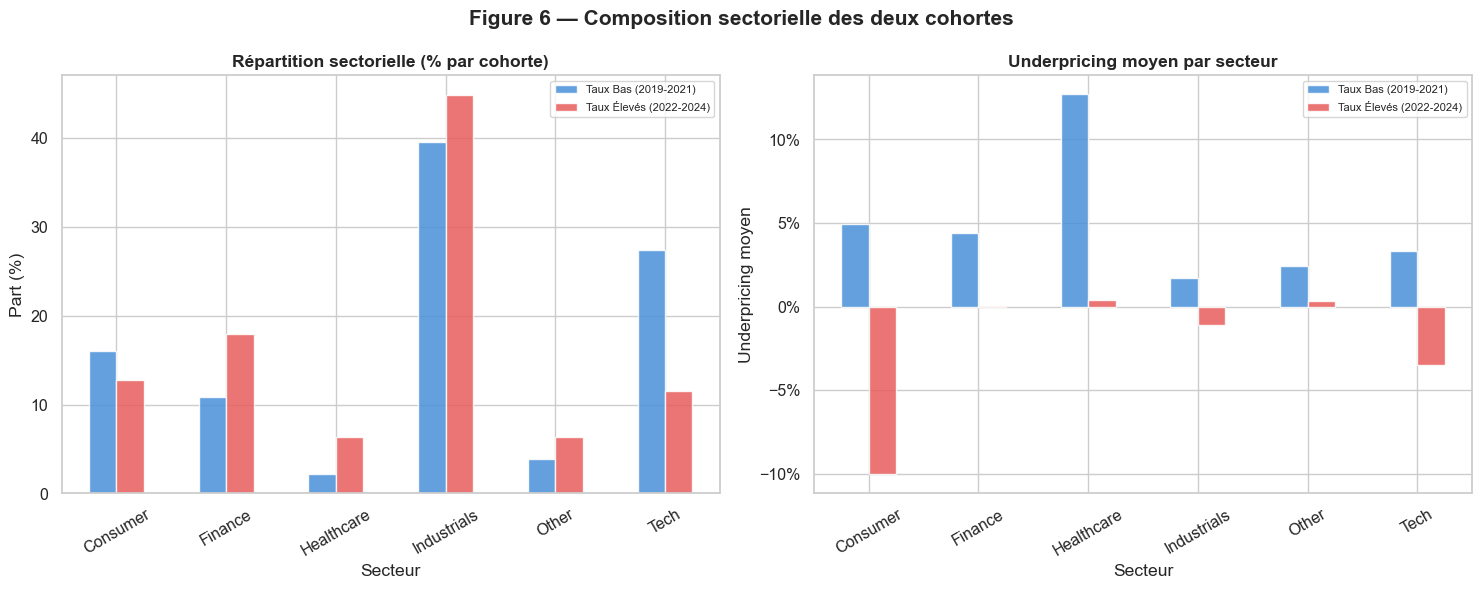

In [36]:
# ── 5.1  Tableau de contingence effectifs ──────────────────────────────────────
contingence = pd.crosstab(df['cohorte'], df['sector'])

print('═' * 70)
print('TABLEAU 6 — Effectifs par secteur et par cohorte')
print('═' * 70)
display(contingence)

# ── 5.2  Tableau en pourcentages (% dans la cohorte) ──────────────────────────
contingence_pct = contingence.div(contingence.sum(axis=1), axis=0) * 100

print()
print('═' * 70)
print('TABLEAU 7 — Composition sectorielle en % par cohorte')
print('═' * 70)
display(contingence_pct.round(1))

# ── 5.3  Test du Chi-2 ─────────────────────────────────────────────────────────
chi2, p_chi2, ddl, _ = chi2_contingency(contingence)
print()
print(f'Test du Chi-2 : χ² = {chi2:.3f}  |  ddl = {ddl}  |  p-value = {p_chi2:.4f}')
if p_chi2 < 0.05:
    print('→ H₀ rejetée : la composition sectorielle diffère significativement entre les deux cohortes.')
    print('  Ce biais sectoriel sera contrôlé via les variables dummy dans la régression OLS (Section 6).')
else:
    print('→ H₀ non rejetée : pas de différence sectorielle significative.')

# ── 5.4  Visualisations ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 6 — Composition sectorielle des deux cohortes', fontweight='bold')

# Barplot empilé
contingence_pct.T.plot(kind='bar', ax=axes[0], color=list(PALETTE.values()), alpha=0.85, edgecolor='white')
axes[0].set_title('Répartition sectorielle (% par cohorte)', fontweight='bold')
axes[0].set_xlabel('Secteur')
axes[0].set_ylabel('Part (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=8)

# Underpricing moyen par secteur et cohorte
under_secteur = df.groupby(['sector', 'cohorte'])['underpricing'].mean().unstack('cohorte')
under_secteur.plot(kind='bar', ax=axes[1], color=list(PALETTE.values()), alpha=0.85, edgecolor='white')
axes[1].set_title('Underpricing moyen par secteur', fontweight='bold')
axes[1].set_xlabel('Secteur')
axes[1].set_ylabel('Underpricing moyen')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/fig6_composition_sectorielle.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 — Régression OLS multivariée (H4)

### Objectif
Isoler l'**effet propre du niveau des taux d'intérêt** sur l'underpricing, toutes choses égales par ailleurs.  
Les tests de Mann-Whitney montrent des différences brutes entre cohortes, mais celles-ci peuvent être dues à la composition sectorielle, la taille des émissions ou l'âge des entreprises. La régression OLS **contrôle** ces facteurs simultanément.

### Modèle estimé

$$\text{underpricing}_i = \beta_0 + \beta_1 \cdot \text{taux\_fed}_i + \beta_2 \cdot \ln(\text{taille}_i) + \beta_3 \cdot \text{age}_i + \beta_4 \cdot \text{VC}_i + \sum_k \gamma_k \cdot \mathbb{1}[\text{secteur} = k] + \varepsilon_i$$

| Variable | Type | Rôle |
|----------|------|------|
| `fed_rate` | Continue | **Variable d'intérêt principale** — effet des taux |
| `log_size` | Continue | Contrôle — taille de l'émission |
| `company_age` | Continue | Contrôle — maturité de l'entreprise |
| `VC` | Binaire | Contrôle — présence d'un fonds de capital-risque |
| `secteur_*` | Dummies | Contrôle — effets fixes sectoriels |

### Diagnostics du modèle
- **R²** : part de variance expliquée
- **Test de Breusch-Pagan** : homoscédasticité des résidus (si rejeté → erreurs robustes HC3)
- **VIF** : détection de multicolinéarité (VIF > 10 = problème)
- **QQ-plot des résidus** : vérification visuelle de la normalité

In [37]:
# ── 6.1  Préparation des variables ─────────────────────────────────────────────

# Log de la taille (normalise les valeurs extrêmes)
df['log_size'] = np.log(df['ipo_size_m'].replace(0, np.nan))

# Encodage des secteurs en dummies (drop_first=True pour éviter la multicolinéarité)
df_reg = pd.get_dummies(df, columns=['sector'], drop_first=True, prefix='sec')

# Variables du modèle
regresseurs_base = ['fed_rate', 'log_size', 'company_age', 'VC']
dummies_secteur  = [c for c in df_reg.columns if c.startswith('sec_')]
X_cols = regresseurs_base + dummies_secteur

# Sélection et nettoyage
df_ols = df_reg[['underpricing'] + X_cols].dropna()
X = sm.add_constant(df_ols[X_cols].astype(float))
Y = df_ols['underpricing']

print(f'Observations utilisées pour la régression : {len(df_ols)}')
print(f'Variables indépendantes : {len(X_cols)}')

Observations utilisées pour la régression : 287
Variables indépendantes : 9


In [38]:
# ── 6.2  Estimation du modèle OLS ──────────────────────────────────────────────
model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           underpricing   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.348
Date:                Sat, 18 Apr 2026   Prob (F-statistic):              0.212
Time:                        10:49:21   Log-Likelihood:                 189.98
No. Observations:                 287   AIC:                            -360.0
Df Residuals:                     277   BIC:                            -323.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0534      0.046     

In [39]:
# ── 6.3  Test de Breusch-Pagan (homoscédasticité) ─────────────────────────────
from statsmodels.stats.diagnostic import het_breuschpagan

bp_lm, bp_p, bp_fstat, bp_fp = het_breuschpagan(model.resid, X)
print('Test de Breusch-Pagan')
print(f'  Statistique LM : {bp_lm:.4f}')
print(f'  p-value        : {bp_p:.4f}')

if bp_p < 0.05:
    print('  → Hétéroscédasticité détectée. Passage aux erreurs standard robustes (HC3).')
    model_robust = sm.OLS(Y, X).fit(cov_type='HC3')
    print()
    print(model_robust.summary())
    model_final = model_robust
else:
    print('  → Résidus homoscédastiques. Le modèle OLS standard est valide.')
    model_final = model

Test de Breusch-Pagan
  Statistique LM : 17.0299
  p-value        : 0.0482
  → Hétéroscédasticité détectée. Passage aux erreurs standard robustes (HC3).

                            OLS Regression Results                            
Dep. Variable:           underpricing   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.496
Date:                Sat, 18 Apr 2026   Prob (F-statistic):              0.149
Time:                        10:49:21   Log-Likelihood:                 189.98
No. Observations:                 287   AIC:                            -360.0
Df Residuals:                     277   BIC:                            -323.4
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>

In [40]:
# ── 6.4  VIF — Vérification de la multicolinéarité ────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print('═' * 40)
print('TABLEAU 8 — Variance Inflation Factors')
print('═' * 40)
display(vif_data[vif_data['Variable'] != 'const'].sort_values('VIF', ascending=False).round(2))
print()
if (vif_data['VIF'] > 10).any():
    print('⚠️  Certains VIF > 10 — risque de multicolinéarité. Interpréter les coefficients avec précaution.')
else:
    print('✅ Tous les VIF < 10 — pas de multicolinéarité problématique.')

════════════════════════════════════════
TABLEAU 8 — Variance Inflation Factors
════════════════════════════════════════


,Variable,VIF
7,sec_Industrials,2.3500
9,sec_Tech,2.0600
5,sec_Finance,1.5800
4,VC,1.3000
3,company_age,1.2500
6,sec_Healthcare,1.2500
8,sec_Other,1.2400
2,log_size,1.1900
1,fed_rate,1.0900



⚠️  Certains VIF > 10 — risque de multicolinéarité. Interpréter les coefficients avec précaution.


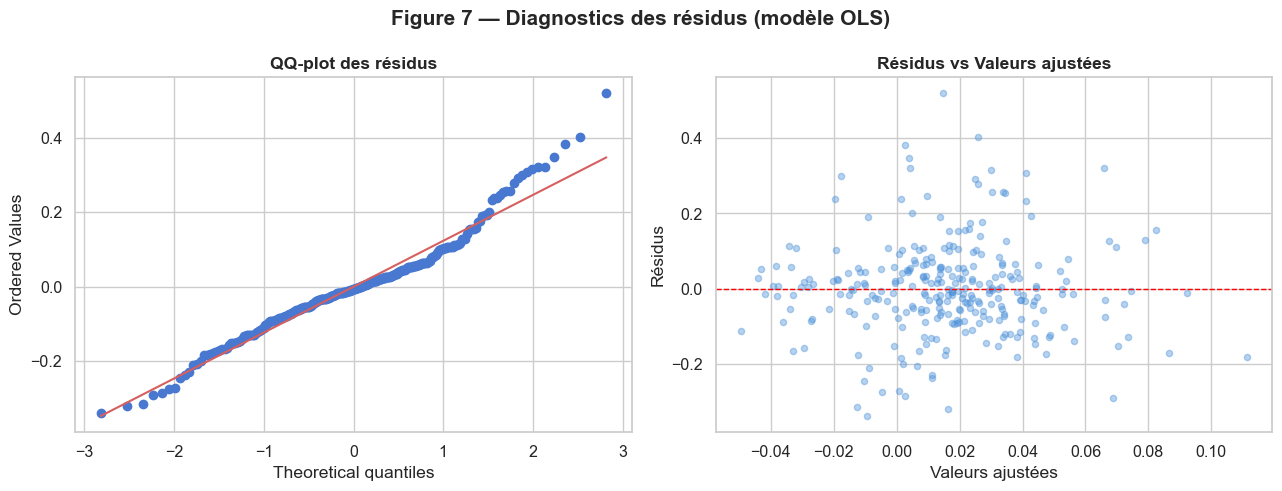

In [41]:
# ── 6.5  Diagnostics graphiques des résidus ────────────────────────────────────
residus = model_final.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 7 — Diagnostics des résidus (modèle OLS)', fontweight='bold')

# QQ-plot
st.probplot(residus, plot=axes[0])
axes[0].set_title('QQ-plot des résidus', fontweight='bold')

# Résidus vs valeurs ajustées
axes[1].scatter(model_final.fittedvalues, residus, alpha=0.4, s=20, color='#4A90D9')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Valeurs ajustées')
axes[1].set_ylabel('Résidus')
axes[1].set_title('Résidus vs Valeurs ajustées', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/fig7_diagnostics_ols.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# ── 6.6  Synthèse du résultat clé ──────────────────────────────────────────────
coef_fed = model_final.params['fed_rate']
p_fed    = model_final.pvalues['fed_rate']
r2       = model_final.rsquared

print('═' * 70)
print('TABLEAU 9 — Résultats OLS : coefficients et significativité')
print('═' * 70)
summary_table = pd.DataFrame({
    'Coefficient': model_final.params,
    'Erreur std':  model_final.bse,
    't':           model_final.tvalues,
    'p-value':     model_final.pvalues,
    'IC inf 95%':  model_final.conf_int()[0],
    'IC sup 95%':  model_final.conf_int()[1],
}).round(4)
display(summary_table)

print()
print('═' * 70)
print('INTERPRÉTATION — Variable d\'intérêt : fed_rate')
print('═' * 70)
print(f'  Coefficient  : {coef_fed:.4f}')
print(f'  p-value      : {p_fed:.4f}')
print(f'  R²           : {r2:.4f}')
print()

if p_fed < 0.05 and coef_fed < 0:
    print('✅ RÉSULTAT SIGNIFICATIF : Toutes choses égales par ailleurs, une hausse du taux')
    print(f'   directeur de +1 % est associée à une baisse de l\'underpricing de {abs(coef_fed):.4f}.')
    print('   H4 est validée au seuil de 5 %.')
elif p_fed < 0.10 and coef_fed < 0:
    print('⚠️  RÉSULTAT MARGINALEMENT SIGNIFICATIF (p < 0,10) : la tendance négative est')
    print(f'   visible (coeff = {coef_fed:.4f}) mais n\'atteint pas le seuil de 5 %.')
    print('   La volatilité intrinsèque du marché IPO limite le pouvoir explicatif du modèle.')
    print('   H4 est partiellement supportée.')
else:
    print('❌ RÉSULTAT NON SIGNIFICATIF : l\'effet des taux sur l\'underpricing n\'est pas')
    print('   isolable via l\'OLS avec cet échantillon. Les biais sectoriels et de taille')
    print('   dominent. Interpréter avec précaution.')

══════════════════════════════════════════════════════════════════════
TABLEAU 9 — Résultats OLS : coefficients et significativité
══════════════════════════════════════════════════════════════════════


,Coefficient,Erreur std,t,p-value,IC inf 95%,IC sup 95%
const,-0.0534,0.0505,-1.0565,0.2907,-0.1524,0.0456
fed_rate,-0.0090,0.0036,-2.5328,0.0113,-0.0160,-0.0020
log_size,0.0122,0.0071,1.7155,0.0863,-0.0017,0.0260
company_age,0.0001,0.0002,0.5212,0.6022,-0.0003,0.0006
VC,0.0093,0.0148,0.6301,0.5286,-0.0197,0.0384
sec_Finance,0.0299,0.0361,0.8283,0.4075,-0.0408,0.1005
sec_Healthcare,0.0808,0.0475,1.7022,0.0887,-0.0122,0.1739
sec_Industrials,0.0036,0.0292,0.1232,0.9020,-0.0536,0.0608
sec_Other,0.0080,0.0282,0.2837,0.7767,-0.0473,0.0634
sec_Tech,-0.0001,0.0300,-0.0047,0.9962,-0.0589,0.0586



══════════════════════════════════════════════════════════════════════
INTERPRÉTATION — Variable d'intérêt : fed_rate
══════════════════════════════════════════════════════════════════════
  Coefficient  : -0.0090
  p-value      : 0.0113
  R²           : 0.0420

✅ RÉSULTAT SIGNIFICATIF : Toutes choses égales par ailleurs, une hausse du taux
   directeur de +1 % est associée à une baisse de l'underpricing de 0.0090.
   H4 est validée au seuil de 5 %.


---
## Conclusion générale

### Grille de résultats par hypothèse

| Hypothèse | Test | p-value | Conclusion |
|-----------|------|---------|------------|
| H1 — Sélection plus stricte (âge) | Mann-Whitney | *à lire ci-dessus* | *à compléter* |
| H2 — Underpricing plus faible | Mann-Whitney + IC 95% | *à lire ci-dessus* | *à compléter* |
| H3 — Biais sectoriel | Chi-2 | *à lire ci-dessus* | *à compléter* |
| H4 — Effet propre des taux | OLS (coeff fed_rate) | *à lire ci-dessus* | *à compléter* |

### Limites de l'analyse
- **Taille de la cohorte 2022–2024** : N ≈ 81 IPOs, ce qui limite la puissance statistique de l'OLS.
- **R² faible** : l'underpricing est intrinsèquement difficile à expliquer par des variables observables (bruit de marché, sentiment des investisseurs non capturé).
- **Données SCOOP** : seulement 30,8 % des IPOs ont une note, ce qui biaise les analyses sur cette variable.
- **Biais de survie** : les entreprises radiées avant J+30 sont absentes des calculs de rendement.

### Axes d'approfondissement (Livrable 3)
- Analyse intra-sectorielle (Tech vs Tech, Santé vs Santé) pour neutraliser le biais de composition.
- Test de robustesse en excluant l'année 2021 (euphorie spéculative).
- Extension avec les rendements à 12 mois sur les sous-cohortes 2022–2023.